In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import re
import sklearn

We first want to test different dimensionality reduction techniques to 7 dimensions, because that is how many dimensions the Spyder chart will have. We will simply use the MSE of the reconstruction as a metric for how each model performs. 

We also want to investigate how data imputation affects the model performance.

In a second step we want to cluster players in order to potentially identify some player roles. This might allow us to generate some labels which could make a visualization via UMAP more insightful. To this end the number of latent dimensions can be larger, e.g. 30, and as a metric for model performance we will use the downstream clustering performance. 

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, SparsePCA
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import make_scorer
from sklearn.pipeline import make_pipeline

N_COMPONENTS = 7

csv_file = "train_data.csv"

data_full = pd.read_csv(csv_file)
data_full_standardized = StandardScaler().fit_transform(data_full)
# keep test set for after model selection via cross-validation to evaluate the final model
train_data, test_data = train_test_split(data_full_standardized, test_size=0.2, random_state=42)


# Define a scorer based on reconstruction error
def mse_loss(X, X_reconstructed):
    return np.mean(np.square(X - X_reconstructed))


def scorer(estimator, X, y=None):
    X_reduced = estimator.transform(X)
    X_reconstructed = estimator.inverse_transform(X_reduced)
    return mse_loss(X, X_reconstructed)

# reconstruction_scorer = make_scorer(reconstruction_error, greater_is_better=False)

# Set up PCA and cross-validation
pca = PCA(n_components=N_COMPONENTS, random_state=42)
sparse_pca = SparsePCA(n_components=N_COMPONENTS, random_state=42)
cv = KFold(n_splits=5, random_state=42, shuffle=True)

# pca.fit(data_full_train)
# sparse_pca.fit(data_full_train)

scores_pca = cross_val_score(pca, train_data, cv=cv, scoring=scorer)
print(f"PCA Score: {scores_pca.mean()}")

pca = pca.fit(train_data)
variance_explained = pca.explained_variance_ratio_
print(variance_explained)
print(f"Variance explained by {N_COMPONENTS} components: {variance_explained.sum() * 100}%")


# scores_sparse_pca = cross_val_score(sparse_pca, test_data, cv=cv, scoring=scorer)
# print(f"SparsePCA Score: {scores_sparse_pca.mean()}")


PCA Score: 0.3586305537535517
[0.266183   0.14541403 0.06684619 0.05550633 0.04125207 0.03713633
 0.03176779]
Variance explained by 7 components: 64.41057350506544%


SparsePCA and PCA have approximately the same performance on reconstruction. Hence, might be better to use SparsePCA due to interpretability? We continue by testing out a very simple Autoencoder.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils

DROP_OUT = 0.2

class ScaledSigmoid(nn.Module):
    def __init__(self, scale=100):
        super(ScaledSigmoid, self).__init__()
        self.scale = scale

    def forward(self, x):
        return self.scale * torch.sigmoid(x)

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, input_dim // 3),
            # nn.Dropout(p=DROP_OUT), # add dropout layer to prevent overfitting
            nn.ReLU(),
            nn.Linear(input_dim // 3, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, hidden_dim),
            # ScaledSigmoid(scale=10)
        )

    def forward(self, x):
        return self.encoder(x)
        
class Decoder(nn.Module):
    def __init__(self, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, output_dim // 3),
            # nn.Dropout(p=DROP_OUT), # add dropout layer to prevent overfitting
            nn.ReLU(),
            nn.Linear(output_dim // 3, output_dim // 2),
            nn.ReLU(),
            nn.Linear(output_dim // 2, output_dim),
        )

    def forward(self, x):
        return self.decoder(x)

class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim)
        self.decoder = Decoder(hidden_dim, input_dim)

    def forward(self, x):
        return self.decoder(self.encoder(x))
    

In [ ]:
# HYPERPARAMETERS
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 500
LAMBDA = 0

model = Autoencoder(train_data.shape[1], N_COMPONENTS)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0)
criterion = nn.MSELoss()
train_loader = data_utils.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data_utils.DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

# Define a loss function with L1 regularization
def l1_regularization(encoder, lambda_l1=LAMBDA):
    l1_reg = torch.tensor(0.0, requires_grad=True)
    for name, param in encoder.named_parameters():
        if "bias" not in name:
            l1_reg = l1_reg + torch.norm(param, 1)
    return lambda_l1 * l1_reg


def epoch_train(model, data_loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    # Create a DataLoader for the dataset

    for i, x in enumerate(data_loader):
        optimizer.zero_grad()
        x = torch.tensor(x).float()
        x_reconstructed = model(x)
        l1_norm = sum(p.abs().sum() for p in model.encoder.parameters())
        loss = criterion(x_reconstructed, x) + LAMBDA * l1_norm
        # loss = criterion(x_reconstructed, x)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(data_loader)

# Define a function to plot the evolution of the loss during training
def plot_loss(train_loss, test_loss):
    # train_loss and test_loss are lists containing the loss at each epoch
    plt.plot(train_loss, label='Train Loss')
    plt.plot(test_loss, label='Test Loss')
    plt.legend()
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

def epoch_test(model, data, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for i, x in enumerate(data):
            x = torch.tensor(x).float()
            x_reconstructed = model(x)
            loss = criterion(x_reconstructed, x)
            running_loss += loss.item()
    return running_loss / len(data)

train_loss_epochs = []
test_loss_epochs = []
for epoch in range(EPOCHS):
    train_loss = epoch_train(model, train_loader, optimizer, criterion)
    test_loss = epoch_test(model, test_loader, criterion)
    train_loss_epochs.append(train_loss)
    test_loss_epochs.append(test_loss)
    print(f"Epoch {epoch} Train Loss: {train_loss} Test Loss: {test_loss}")
    # Plot evolution of loss

plot_loss(train_loss_epochs, test_loss_epochs)


In [5]:
# for name, param in model.named_parameters():
#     print(f"{name} {param.grad}")

def count_encoder_weights(model):
    nweights = 0
    for name, weights in model.encoder.named_parameters():
        if 'bias' not in name:
            nweights = nweights + weights.numel()
    return nweights

def count_encoder_zero_weights(model):
    nzero = 0
    for name, weights in model.encoder.named_parameters():
        if 'bias' not in name:
            nzero = nzero + torch.sum(weights < 1e-5).item()
    return nzero

# print(f"Number of weights: {count_encoder_weights(model)}")
# print(f"Number of zero weights: {count_encoder_zero_weights(model)}")
# for param in model.encoder.parameters():
#     print(param)

# Get an insight in how the encoded data looks like
model.eval()
encoded_data = model.encoder(torch.tensor(data_full_standardized).float()).detach().numpy()
encoded_data = pd.DataFrame(encoded_data, columns=[f"component_{i}" for i in range(N_COMPONENTS)])
# print(encoded_data.head())

Try to create a model for offensive stats only. 

TODO: describe idea of model

In [6]:
OFFENSIVE_FEATURES = ['points', "points per player's possession", 'field goals made', 'field goals attempted', 'field goals, %', 
                      '3-pt field goals made', '3-pt field goals attempted', '3-pt field goals, %', 'free throws made', 
                      'free throws attempted', 'free throws, %', 'assists', '2-pt field goals made', '2-pt field goals attempted', 
                      '2-pt field goals, %', 'points off assists', 'screen assist', 'points off screen assists', 
                      "number of player's possessions", 'team points with player', 'offensive rating', 
                      'assists to turnovers', 'true shooting percentage', 'effective field goal percentage', 'uncontested field goals made', 
                      'uncontested field goals', 'contested field goals made', 'contested field goals', 'transitions made', 'transitions attempted', 'catch and shoot made', 
                      'catch and shoot attempted', 'catch and drive made', 'catch and drive attempted', 'screens off made', 
                      'screens off attempted', 'posts up made', 'posts up attempted', 'isolations made', 'isolations attempted', 
                      'hand off made', 'hand off attempted', 'cuts made', 'cuts attempted', 'pnr handlers made', 'pnr handlers attempted', 
                      'pnp made', 'pnp attempted', 'drives made', 'drives with shot',
                      'right drives made', 'right drives', 'left drives made', 'left drives',
                      ]



csv_file = "train_data.csv"

data_full = pd.read_csv(csv_file)
off_data = data_full[OFFENSIVE_FEATURES]
print(f"Number of offensive features: {len(off_data.columns)} out of {len(data_full.columns)}")
off_data_standardized = StandardScaler().fit_transform(off_data)

# keep test set for after model selection via cross-validation to evaluate the final model
# Might not need the train-test-split here because unsupervised learning
train_data, test_data = train_test_split(off_data_standardized, test_size=0.2, random_state=42)

Number of offensive features: 54 out of 93


Reduce dimensions to about 30 s.t. it can better be clustered. Use CV (or other validation techniques) to determine a cluster size.

[0.31672695 0.19980169 0.09731388 0.06934674 0.05030434 0.03382868
 0.0306383  0.02439943 0.01955277 0.01661761 0.01568237 0.01342449
 0.01158189 0.01063111 0.01031582]
Variance explained by 15 components: 92.01660528344013%


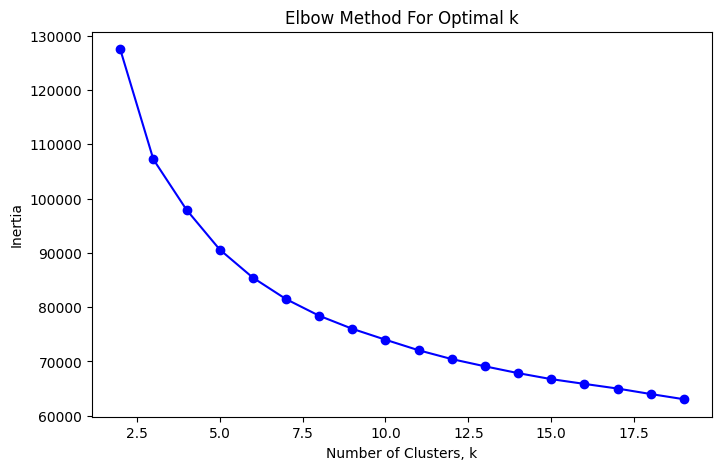

In [7]:
from sklearn.cluster import KMeans

n_components = 15
pca = PCA(n_components=n_components, random_state=42)
cv = KFold(n_splits=5, random_state=42, shuffle=True)

pca.fit(off_data_standardized)
variance_explained = pca.explained_variance_ratio_
print(variance_explained)
print(f"Variance explained by {n_components} components: {variance_explained.sum() * 100}%")
# Use the reduced stats for clustering.
off_stats_reduced = pca.transform(off_data_standardized)

# Use the elbow method to determine the number of clusters
inertias = []
num_clusters = np.arange(2, 20)
for k in num_clusters:
    kmeans = KMeans(n_clusters=k, init='k-means++',random_state=42, n_init=10)
    kmeans.fit(off_stats_reduced)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(num_clusters, inertias, 'bo-')
plt.xlabel('Number of Clusters, k')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

#silhouette_scores = pd.DataFrame(silhouette_scores, index=num_clusters)
# Plot silhouette scores
# silhouette_scores.plot()
# plt.title("Silhouette Scores for Different Linkage Methods")


The Elbow method doesn't hint at a clear choice for the number of clusters. We now also perform silhouette analysis as in: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

For n_clusters = 2 The average silhouette_score is : 0.2448516371998955
For n_clusters = 3 The average silhouette_score is : 0.21166998790851832
For n_clusters = 4 The average silhouette_score is : 0.17343715016378564
For n_clusters = 5 The average silhouette_score is : 0.1580539128751921
For n_clusters = 6 The average silhouette_score is : 0.14866597649014102
For n_clusters = 7 The average silhouette_score is : 0.14600534001475735
For n_clusters = 8 The average silhouette_score is : 0.14131016654311362
For n_clusters = 9 The average silhouette_score is : 0.13620552780372255
For n_clusters = 10 The average silhouette_score is : 0.12168174664647914
For n_clusters = 11 The average silhouette_score is : 0.1141437181984825
For n_clusters = 12 The average silhouette_score is : 0.11261211297544434
For n_clusters = 13 The average silhouette_score is : 0.11040789309309754
For n_clusters = 14 The average silhouette_score is : 0.10668456963275821
Calinski-Harabasz Score for 2 clusters: 1155.0541

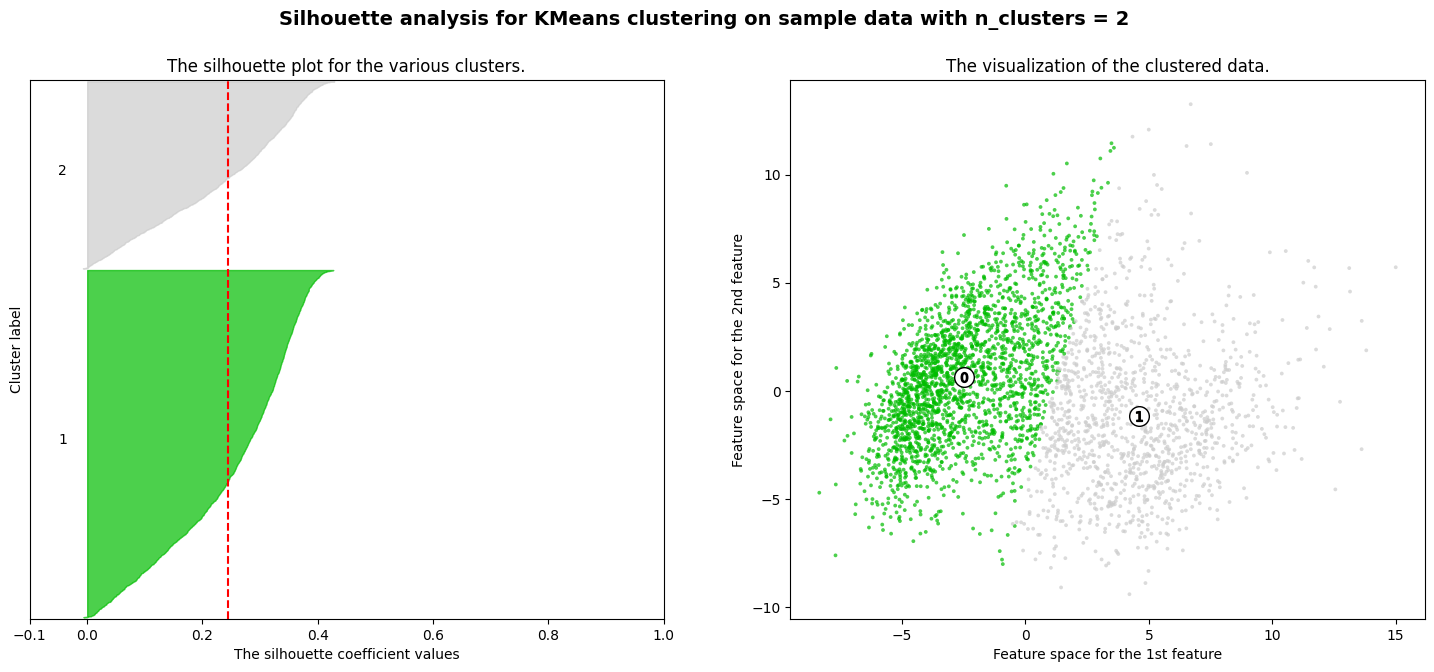

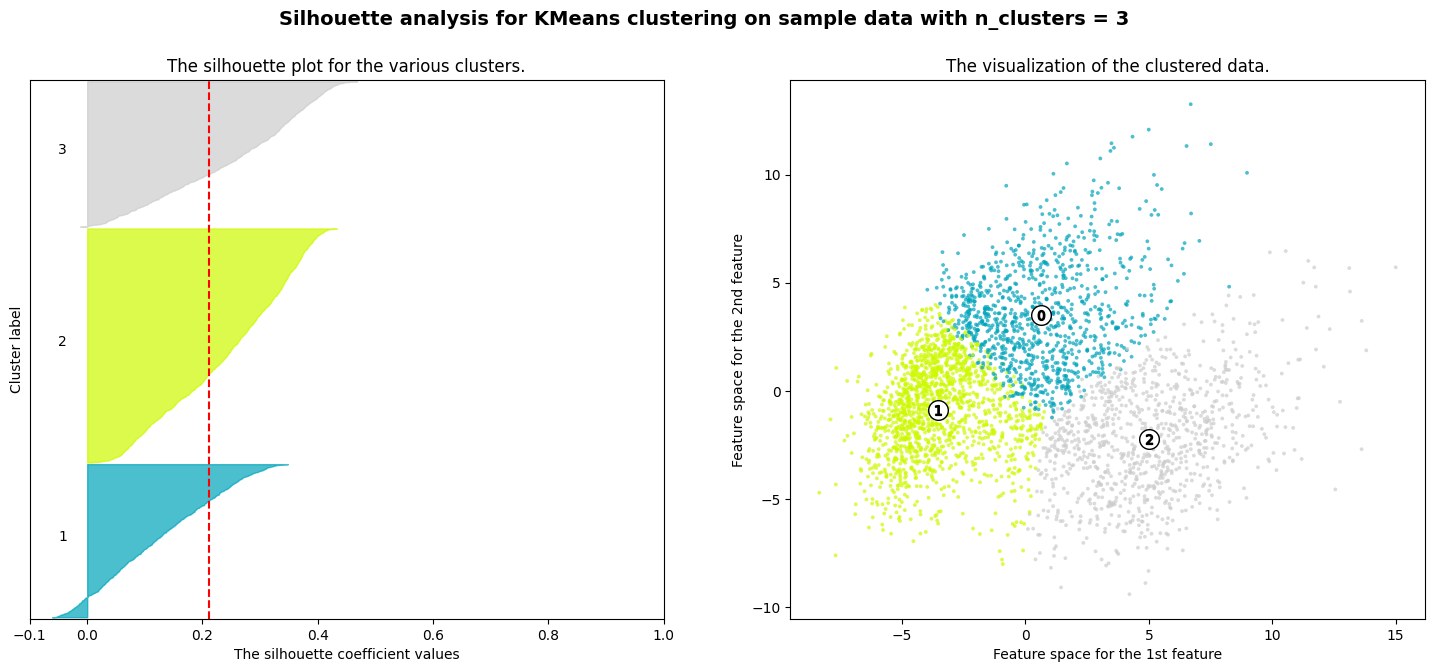

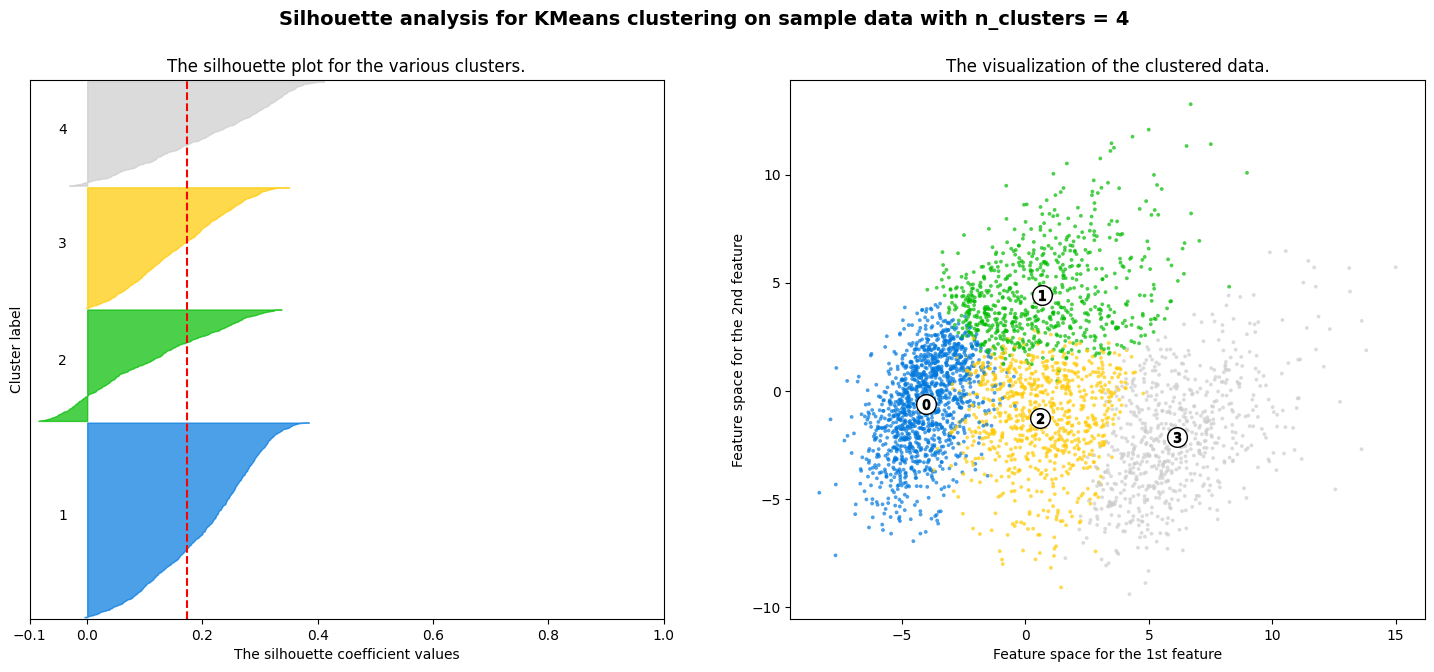

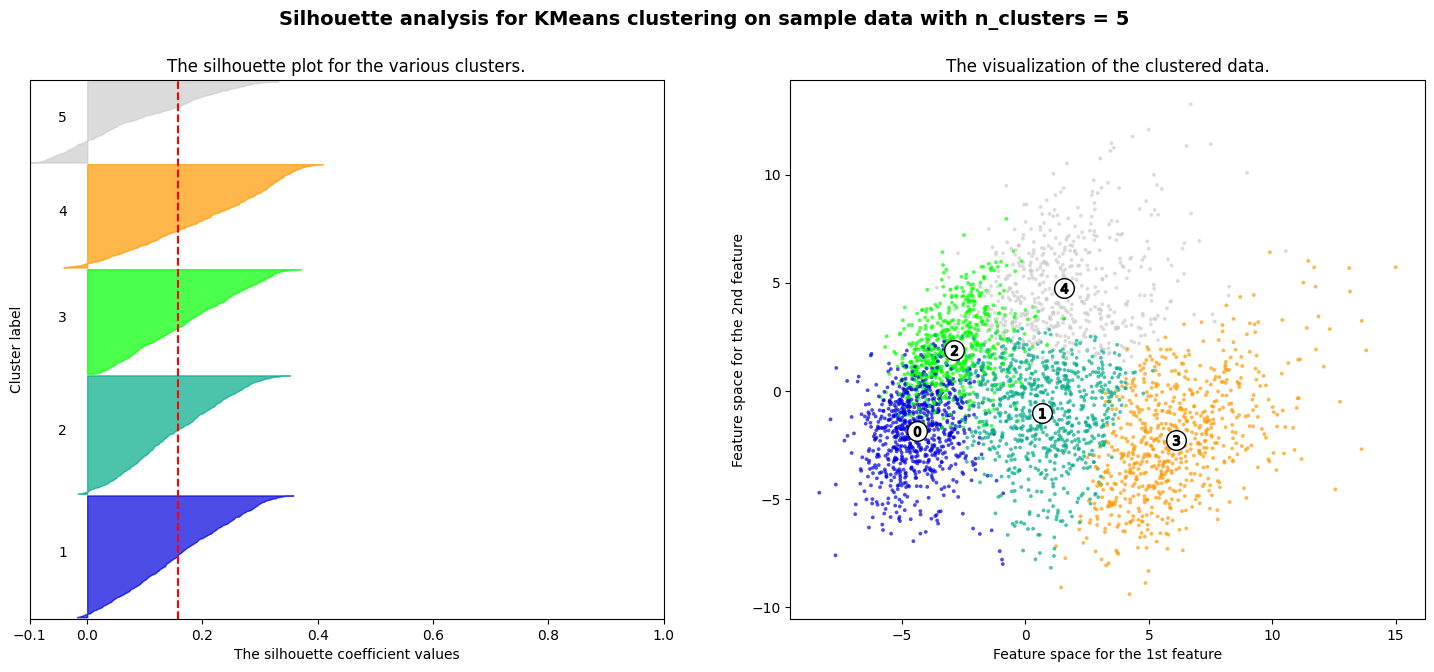

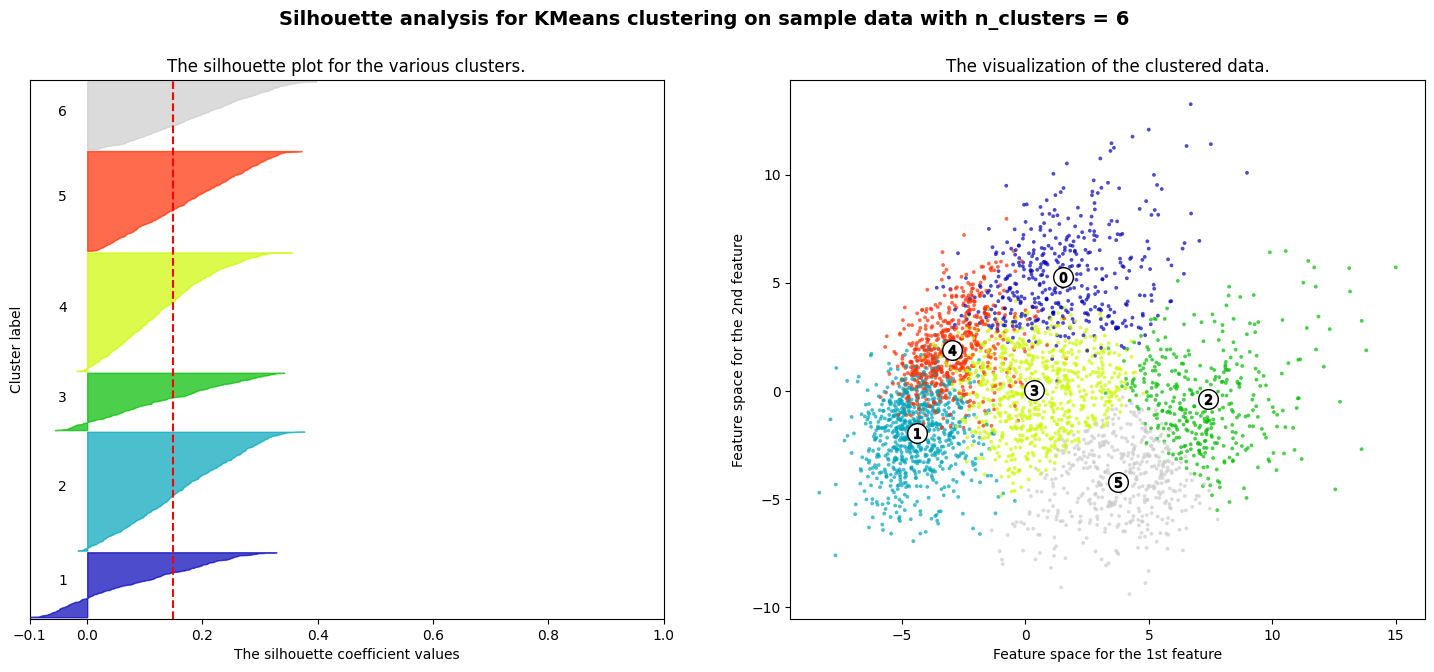

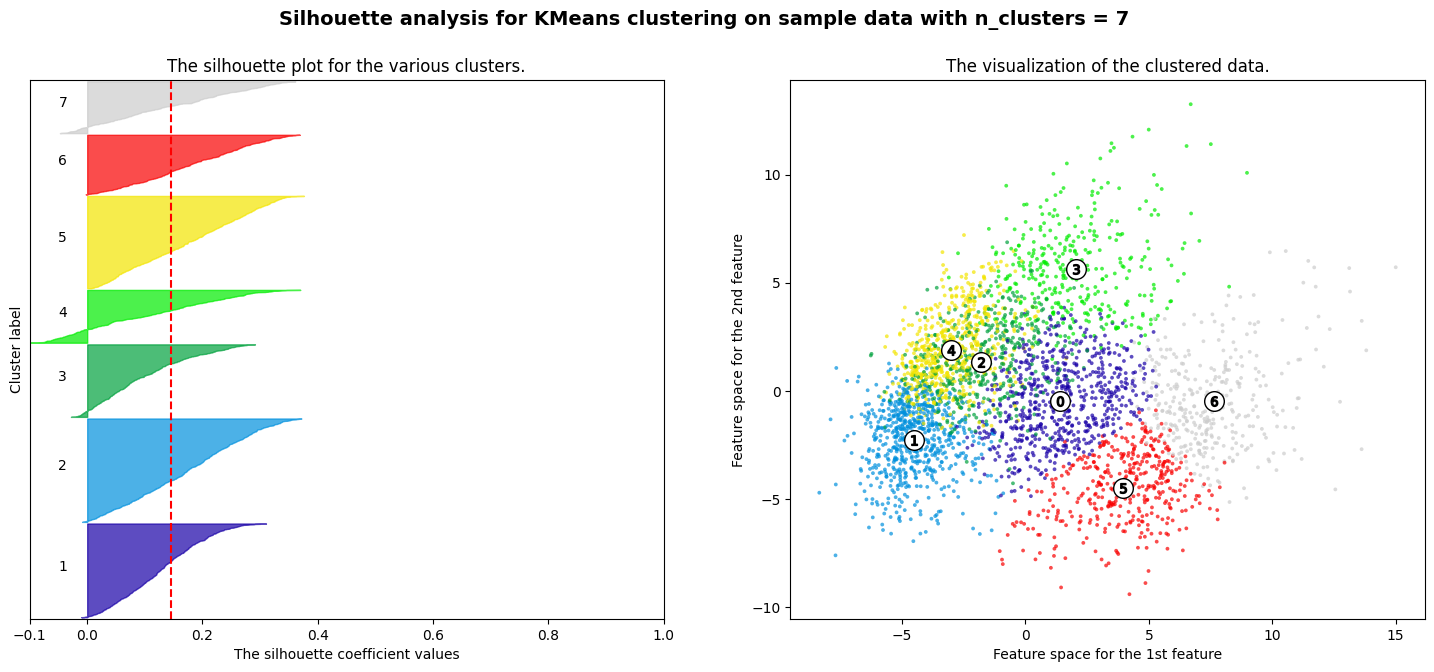

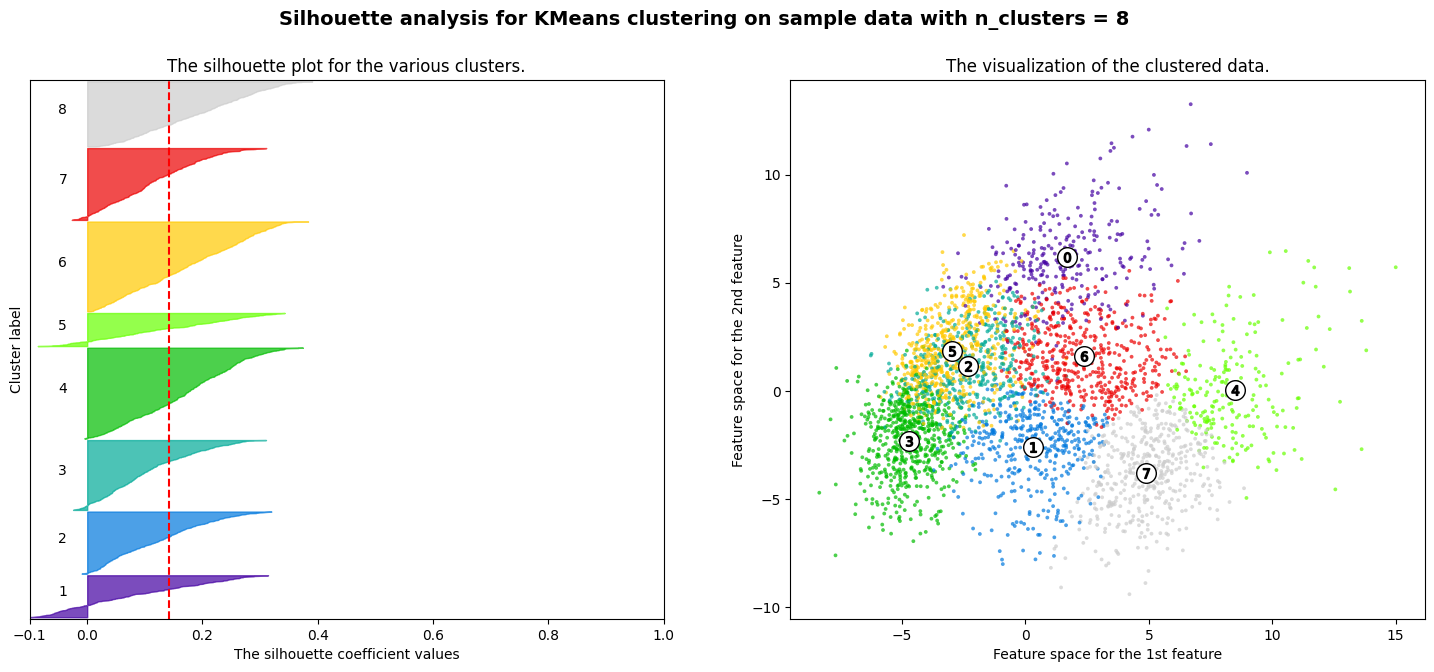

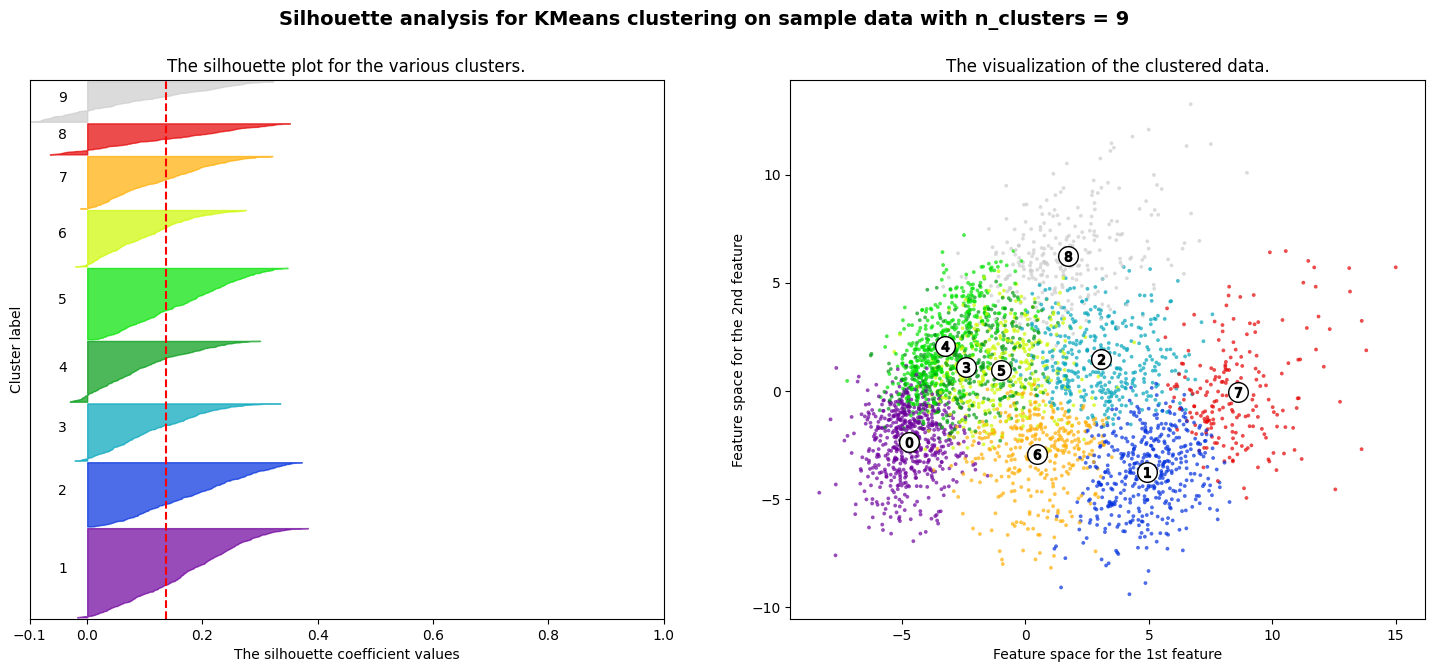

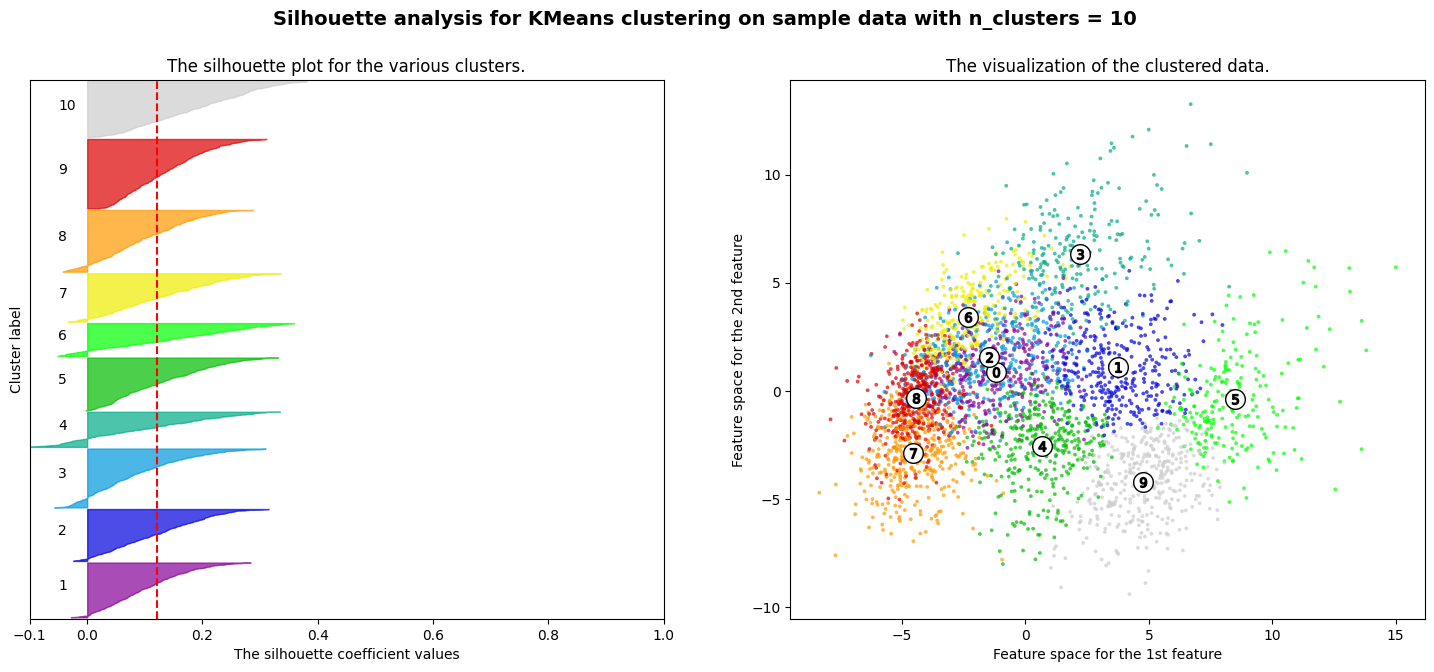

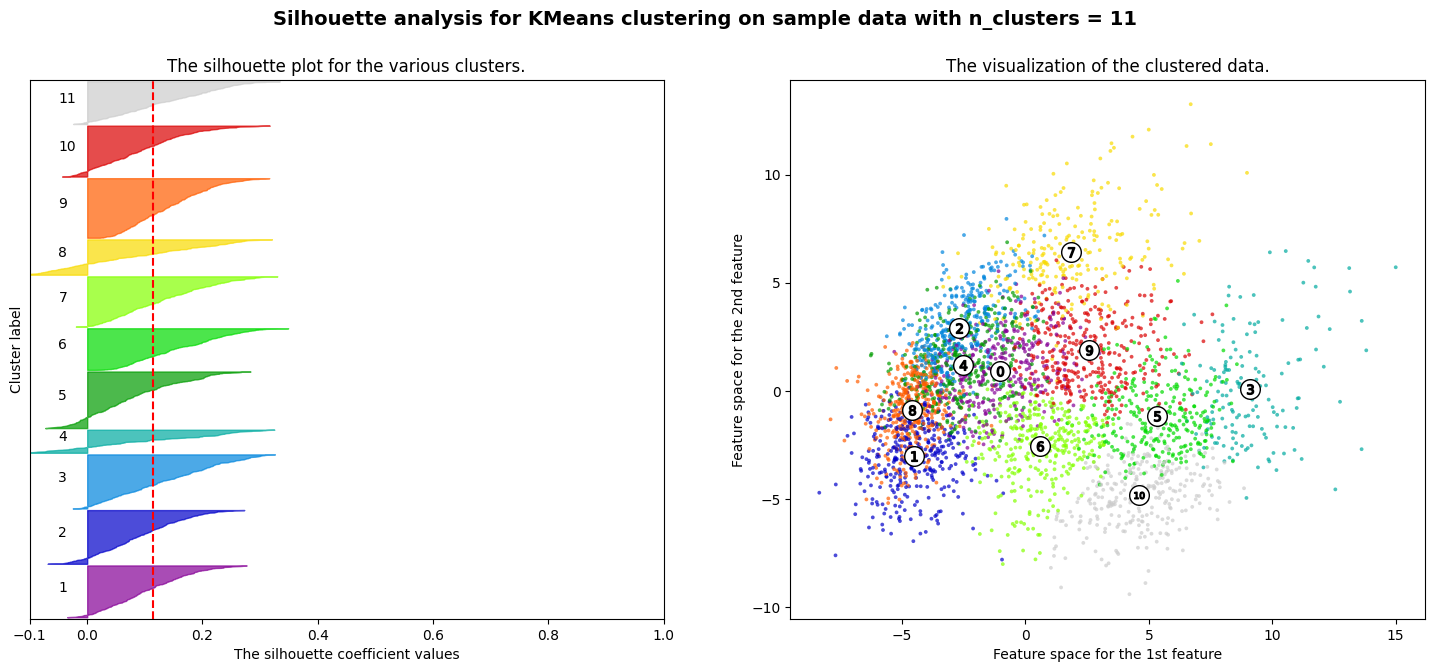

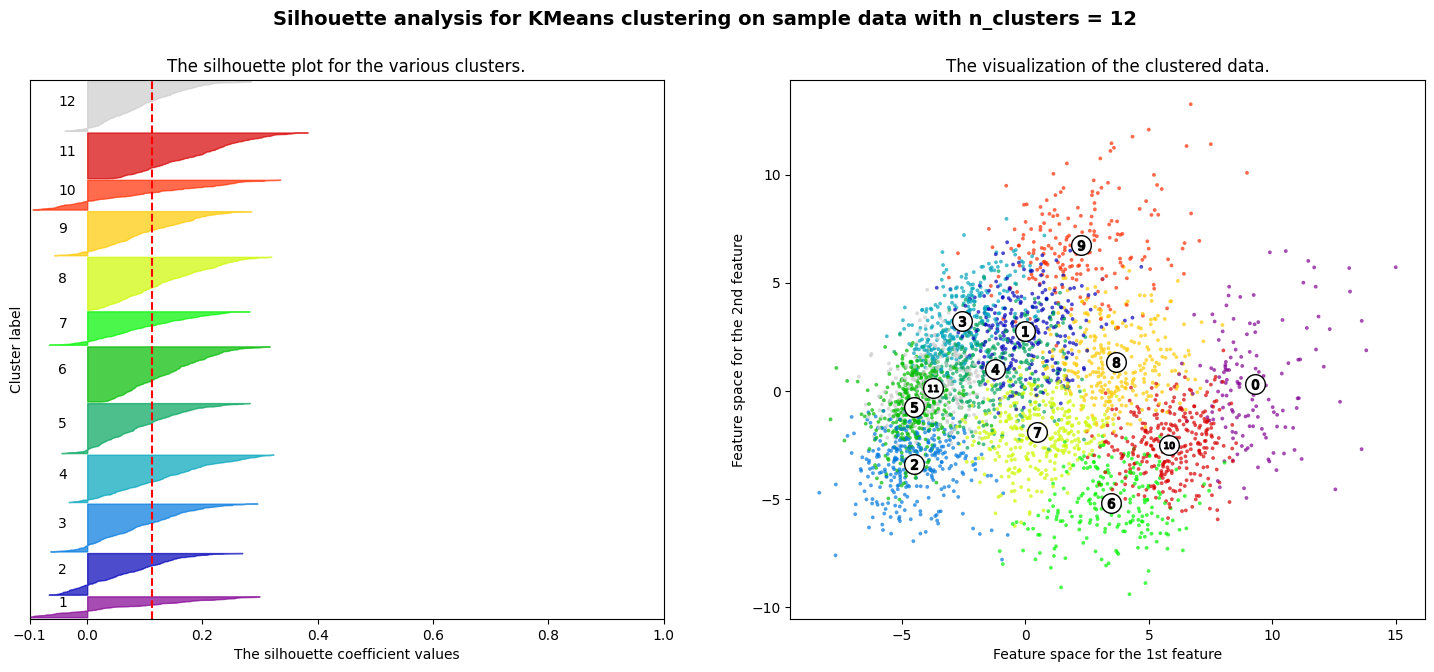

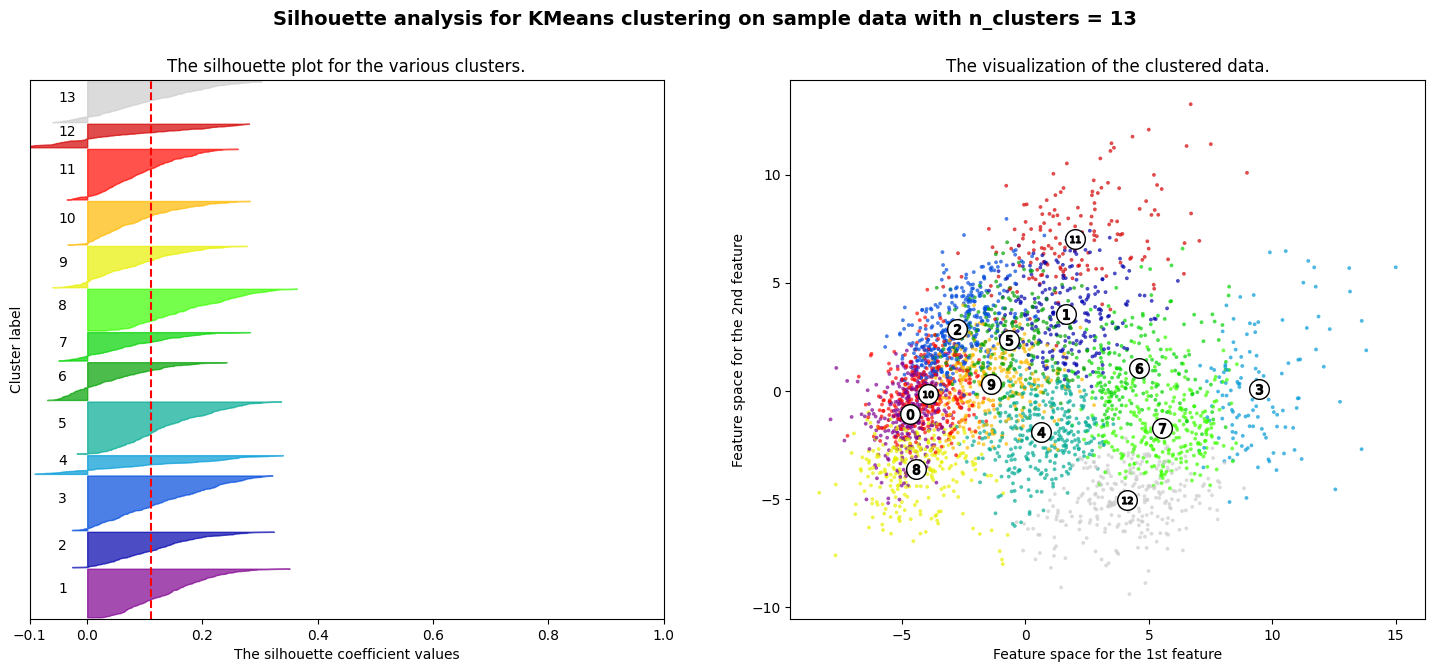

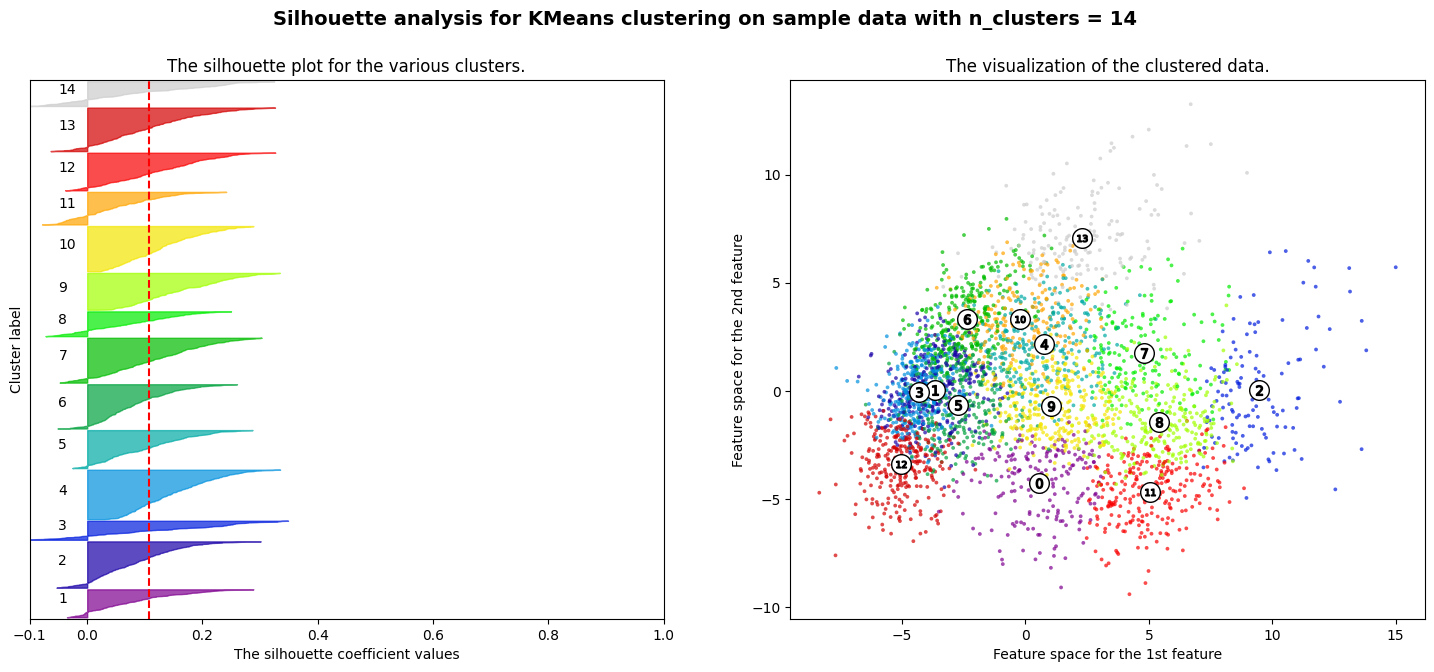

In [8]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples, silhouette_score, calinski_harabasz_score


def plot_silhouette_scores(df, clusterer, num_clusters, labels):
    # Labels start from 0 but colors start from 1. Hence, add 1 to labels.
    labels = labels + 1
    # Set up the silhouette plot
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)
    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 0.5]
    ax1.set_xlim([-0.1, 0.3])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(df) + (num_clusters + 1) * 10])
    silhouette_avg = silhouette_score(df, labels)
    print(
        "For n_clusters =",
        num_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(df, labels)
    y_lower = 10
    for i in range(num_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        label = i + 1
        ith_cluster_silhouette_values = sample_silhouette_values[labels == label]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(label) / num_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(label))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(labels.astype(float) / num_clusters)
    ax2.scatter(
        df[:, 0], df[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % num_clusters,
        fontsize=14,
        fontweight="bold",
    )


# silhouette_scores = []
calinski_harabasz_scores = []
num_clusters = np.arange(2, 15)
for k in num_clusters:
    kmeans = KMeans(n_clusters=k, init='k-means++',random_state=42, n_init=10)
    kmeans.fit(off_stats_reduced)
    plot_silhouette_scores(off_stats_reduced, kmeans, k, kmeans.labels_)
    c_h_score = calinski_harabasz_score(off_stats_reduced, kmeans.labels_)
    calinski_harabasz_scores.append(c_h_score)
    # silhouette_avg = silhouette_score(off_stats_reduced, kmeans.labels_)
    # silhouette_scores.append(silhouette_avg)

for k in num_clusters:
    print(f"Calinski-Harabasz Score for {k} clusters: {calinski_harabasz_scores[k-2]}")

plt.show()


Given the above it seems reasonable to choose somewehere between TBD-TBD clusters. However, the average silhouette scores are pretty low. Hence, we also try out different clustering algorithms:
* Hierarchical clustering
* DBSCAN
* HDBSCAN

Now, also try the hierarchical clustering approach and compare results to regular clustering.

Text(0.5, 1.0, 'Silhouette Scores for Different Linkage Methods')

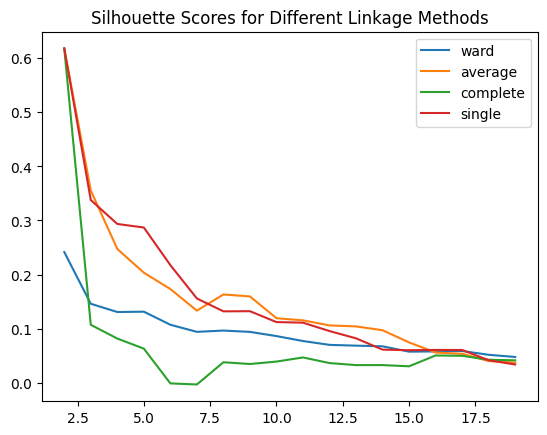

In [9]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Be sure to have a fresh data set
csv_file = "train_data.csv"
data_full = pd.read_csv(csv_file)
off_data = data_full[OFFENSIVE_FEATURES]
# off_data_standardized = StandardScaler().fit_transform(off_data)
# off_stats_reduced = pca.fit_transform(off_data_standardized)

silhouette_scores = {}
num_clusters = np.arange(2, 20)

for i in num_clusters:
    curr_scores = []
    for linkage in ("ward", "average", "complete", "single"):
        clustering = AgglomerativeClustering(linkage=linkage, n_clusters=i, metric='euclidean')
        # clustering.fit(off_data_standardized)
        labels = clustering.fit_predict(off_stats_reduced)
        silhouette_avg = silhouette_score(off_stats_reduced, labels)
        curr_scores.append(silhouette_avg)
    silhouette_scores[i] = curr_scores

silhouette_scores = pd.DataFrame(silhouette_scores, index=["ward", "average", "complete", "single"]).T
# Plot silhouette scores
silhouette_scores.plot()
plt.title("Silhouette Scores for Different Linkage Methods")
# The silhouette score is highest for average and single linkage

We observe that in general we obtain higher silhouette scores via hierarchical clustering compared to kmeans++. The best performance is given by the 'single' linkage with 4 clusters. 

When computing it however, we see that when using 'average' or 'single' we typically have almost all data points in one cluster whereas the remaining clusters each have single digit elements. Hence, in the end it turns out that our original approach, i.e. KMeans++, still performs better. 

Next, try out DBSCAN.

In [10]:
from sklearn.cluster import DBSCAN

count = 0
for eps in np.arange(1, 5.0, 0.2):
    for min_samples in range(200, 1000, 50):
        # n_jobs=-1 allows the algorithm to use all available CPU cores
        db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit(off_stats_reduced)
        if len(np.unique(db.labels_)) > 1:  # More than one cluster found
            count += 1
            score = silhouette_score(off_stats_reduced, db.labels_)
            print(f"EPS: {eps:.1f}, Min Samples: {min_samples}, Clusters: {len(np.unique(db.labels_))}, Silhouette: {score:.2f}")
if count == 0:
    print("No clusters found")

EPS: 3.8, Min Samples: 200, Clusters: 2, Silhouette: -0.06
EPS: 4.0, Min Samples: 200, Clusters: 2, Silhouette: 0.05
EPS: 4.0, Min Samples: 250, Clusters: 2, Silhouette: -0.04
EPS: 4.2, Min Samples: 200, Clusters: 2, Silhouette: 0.10
EPS: 4.2, Min Samples: 250, Clusters: 2, Silhouette: 0.07
EPS: 4.2, Min Samples: 300, Clusters: 2, Silhouette: 0.01
EPS: 4.4, Min Samples: 200, Clusters: 3, Silhouette: 0.09
EPS: 4.4, Min Samples: 250, Clusters: 2, Silhouette: 0.11
EPS: 4.4, Min Samples: 300, Clusters: 2, Silhouette: 0.09
EPS: 4.4, Min Samples: 350, Clusters: 2, Silhouette: 0.06
EPS: 4.6, Min Samples: 200, Clusters: 2, Silhouette: 0.15
EPS: 4.6, Min Samples: 250, Clusters: 3, Silhouette: 0.10
EPS: 4.6, Min Samples: 300, Clusters: 2, Silhouette: 0.14
EPS: 4.6, Min Samples: 350, Clusters: 2, Silhouette: 0.11
EPS: 4.6, Min Samples: 400, Clusters: 2, Silhouette: 0.08
EPS: 4.6, Min Samples: 450, Clusters: 2, Silhouette: 0.03
EPS: 4.8, Min Samples: 200, Clusters: 2, Silhouette: 0.20
EPS: 4.8, Mi

The silhouette scores of the clusters found by DBSCAN are worse than what we had before and tend to only find two clusters. Next, try out HDBSCAN.

In [11]:
from sklearn.cluster import HDBSCAN

count = 0
for eps in np.arange(0.1, 10.0, 0.2):
    df = HDBSCAN(min_cluster_size=300, cluster_selection_epsilon=eps, n_jobs=-1).fit(off_stats_reduced)
    if len(np.unique(db.labels_)) > 1:  # More than one cluster found
        count += 1
        score = silhouette_score(off_stats_reduced, db.labels_)
        print(f"EPS: {eps:.1f}, Min Samples: {min_samples}, Clusters: {len(np.unique(db.labels_))}, Silhouette: {score:.2f}")

if count == 0:
    print("No clusters found")

No clusters found


Given the above, we choose KMeans++ with either 4 or 5 clusters. We investigate each cluster by anlyzing typical values of key basketball metrics such as True Shooting, Points etc.

off_stats_reduced is the data frame where the offensive features have been extracted from the (normalized) full data and have been standardized.

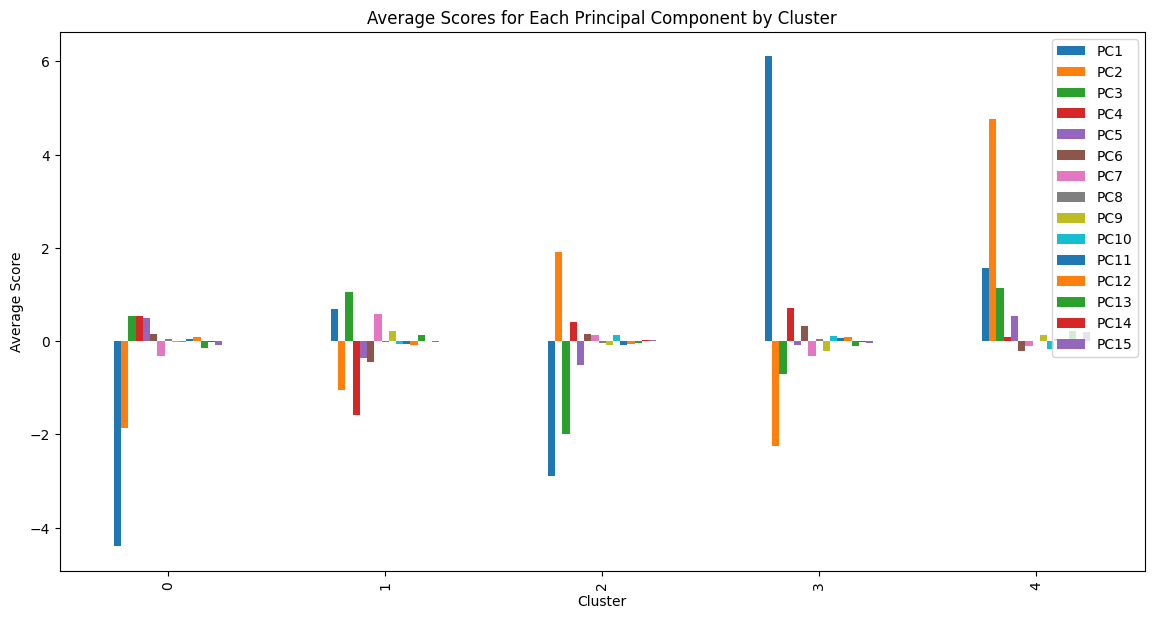

Cluster summaries written to KMeans(n_clusters=5, n_init=10, random_state=42)_cluster_stats.csv


In [12]:
num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(off_stats_reduced)

# Optionally, add cluster labels back to your original DataFrame
# If you want to attach to the original data, do this. Will also attach to off_data because off_data is only a "view"
# of the full dataframe called data_full.

# data_full is NOT standardized but it is normalized
data_full['cluster'] = clusters
# off_stats_reduced['cluster'] = clusters 

# Create a DataFrame for the reduced stats with cluster labels
def analyze_cluster_csv(df_reduced, df, cluster, estimator):
    """
    Assumes that df_reduced (by e.g. PCA) and df have the cluster labels attached.
    """
    # Columns in data frame corresponds to the principal components
    reduced_df = pd.DataFrame(df_reduced, columns=[f'PC{i+1}' for i in range(df_reduced.shape[1])])
    reduced_df['cluster'] = cluster

    # Plotting the mean of each PC for each cluster
    cluster_means = reduced_df.groupby('cluster').mean()
    cluster_means.plot(kind='bar', figsize=(14, 7))
    plt.title('Average Scores for Each Principal Component by Cluster')
    plt.ylabel('Average Score')
    plt.xlabel('Cluster')
    plt.show()
    
    # Detailed stats per cluster for interpretation
    # Unnormalize it such that it is easier to interpret. Load minutes from csv file
    minutes = pd.read_csv('minutes.csv')
    minutes_series = pd.Series(minutes["minutes"])
    df_unnormalized = df.copy()
    df_unnormalized = df_unnormalized.mul(minutes_series, axis=0)
    # print(df_unnormalized.head())

    out_file = f"{str(estimator)}_cluster_stats.csv"
    with open(out_file, 'w') as f:
        f.write("")

    # The below code will reomve the cluster column from the data frame, add it back
    off_data = df_unnormalized[OFFENSIVE_FEATURES].copy()
    off_data['cluster'] = cluster

    # Process each cluster
    for c in range(estimator.n_clusters):
        # Select data for the current cluster
        # print(off_data['cluster'].head())
        cluster_data = off_data[off_data['cluster'] == c]
        # Get the description
        description = cluster_data.describe()
        
        # Write/append the description to a CSV file
        with open(out_file, 'a') as f:
            f.write(f"\nCluster {c}:\n")
            description.to_csv(f)

    print(f"Cluster summaries written to {out_file}")
    
analyze_cluster_csv(off_stats_reduced, data_full, clusters, kmeans)

In [13]:
# from scipy.cluster.hierarchy import dendrogram, linkage

# N_CLUSTERS = 5

# final_cluster = AgglomerativeClustering(linkage="ward", n_clusters=N_CLUSTERS, metric='euclidean')
# labels = final_cluster.fit_predict(off_stats_reduced)
# silhouette_avg = silhouette_score(off_stats_reduced, labels)
# print(f"Silhouette score for {N_CLUSTERS} clusters: {silhouette_avg}")

# off_data['cluster'] = labels

# analyze_cluster(off_stats_reduced, off_data, labels, final_cluster)

# Perform some cluster analysis as before


 # Create Dendrogram, TODO: Not really readable/interpretable

 # We need to sample some random points from the data set to make the dendrogram more readable
 # Always copy data to make sure to not modify the original data
# np.random.seed(42)
# data_copy = off_data_standardized.copy()
# # Now shuffle data and take a random subset, about 300 points
# shuffled_data = np.random.permutation(data_copy)
# sample_ind = np.random.choice(shuffled_data.shape[0], 50, replace=False)
# sample_data = shuffled_data[sample_ind].copy()


# Z = linkage(sample_data, method='single')
# plt.figure(figsize=(40, 20))
# plt.title(f'Dendrogram for single linkage')
# dendrogram(Z)
# plt.show()

Use t-SNE and UMAP to see how it visualizes our clusters for the offensive data.

In [14]:
import umap
from sklearn.manifold import TSNE

umap_embeddings = []
tsne_embeddings = []
# By filtering for offensive features we will also remove the cluster labeling.
without_cluster = data_full[OFFENSIVE_FEATURES]

for i in range(100, 201, 20):
    reducer = umap.UMAP(n_neighbors=i)
    scaled_data = StandardScaler().fit_transform(without_cluster)
    embedding = reducer.fit_transform(scaled_data)
    umap_embeddings.append(embedding)
    print(f"finished for n_neighbors = {i}")

for i in range(5, 51, 5):
    tsne = TSNE(n_components=2, perplexity=i, n_iter=300)
    scaled_data = StandardScaler().fit_transform(without_cluster)
    embedding = tsne.fit_transform(scaled_data)
    tsne_embeddings.append(embedding)
    print(f"finished for perplexity = {i}")

ModuleNotFoundError: No module named 'umap'

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(30, 14))

for i, ax in enumerate(axs.flatten()):
    neighbours = (i * 20) + 100
    if i <= 5:
        ax.scatter(umap_embeddings[i][:, 0], umap_embeddings[i][:, 1], c=data_full['cluster'], cmap="Spectral", s=5)
        ax.set_title(f"n_neighbors: {neighbours}")
    
plt.tight_layout()
plt.legend()
plt.show()

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(30, 20))
for i, ax in enumerate(axs.flatten()):
    perplexity = (i * 5) + 5
    if i <= 9:
        ax.scatter(tsne_embeddings[i][:, 0], tsne_embeddings[i][:, 1], c=data_full['cluster'], cmap="Spectral", s=5)
        ax.set_title(f"perplexity: {perplexity}")

plt.tight_layout()
plt.legend()
plt.show()

Next step: use PCA again to extract three latent dimensions. Ideally, these could then for the Spyder plot, where each of the three hopefully encodes one of the offensive aspects a player might have.

In [ ]:
smaller_pca = PCA(n_components=3, random_state=42)
reduced_3d = smaller_pca.fit_transform(off_data_standardized)
reduced_3d = pd.DataFrame(reduced_3d)

# print variance explained
print(f"Total variance explained by 3 PCs: {smaller_pca.explained_variance_ratio_.sum()}")

reduced_3d['cluster'] = clusters
# Set the aesthetic style of the plots
# sns.set(style="whitegrid")

# Create a KDE plot for each principal component
# plt.figure(figsize=(30, 12))
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 9))
for i, ax in enumerate(axs):
    # i corresponds to the i-th principal component
    for cluster in reduced_3d['cluster'].unique():
        subset = reduced_3d[reduced_3d['cluster'] == cluster]
        sns.kdeplot(subset.iloc[:, i], label=cluster, fill=True, ax=axs[i])
    axs[i].set_title(f'PC{i+1}')
    plt.xlabel('PC {i} Value')
    plt.ylabel('Density')
    plt.legend(title='Clusters')

fig.suptitle('Density Estimates by Cluster for each PC', fontsize=16)
plt.tight_layout()
plt.show()

# # Columns in data frame corresponds to the principal components
# reduced_df = pd.DataFrame(reduced_3d, columns=[f'PC{i+1}' for i in range(reduced_3d.shape[1])])
# reduced_df['cluster'] = data_full['cluster']

# # Plotting the mean of each PC for each cluster
# cluster_means = reduced_df.groupby('cluster').mean()
# cluster_means.plot(kind='bar', figsize=(14, 7))
# plt.title('Average Scores for Each Principal Component by Cluster')
# plt.ylabel('Average Score')
# plt.xlabel('Cluster')
# plt.show()

# Inspect the fitted principal components
# WAY too hard to do....
principal_components = smaller_pca.components_
# print(principal_components)
